#### Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from typing import Dict, Tuple
from pathlib import Path
from scipy.stats import norm, invgamma, multivariate_normal
import pickle
import os

from scipy import stats as scipy_stats
from scipy.stats import skewnorm, t, nct, norminvgauss
from scipy.optimize import minimize
from skewt_scipy.skewt import skewt

from joblib import Parallel, delayed

warnings.filterwarnings('ignore')
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

import contextlib
import io

from kama_msr import KAMA
from kama_msr import MarkovSwitchingModel
from kama_msr import KAMA_MSR
from kmrf import KMRF
from KMRF_training_config import *
from bayesian_forward_simulator import BayesianForwardSimulator
from portfolio_optimizer_inputs import PortfolioOptimizerInputs
from portfolio_optimizer import PortfolioOptimizer

## Data

#### --------------------------------------------------------------------

In [2]:
# Prepare data: etf_close_prices, commodity_close_prices, universe_close_prices
international_index_symbol_names = pd.read_csv('data/inputs/fmp_index_list.csv').set_index('symbol')['name']
international_index_symbol_names = international_index_symbol_names[~international_index_symbol_names.index.isin(['^GSPC', '^NDX'])].to_dict()
commodity_symbol_names = pd.read_csv('data/inputs/fmp_commodity_list.csv').set_index('symbol')['name'].to_dict()
etf_symbol_names = {
    # BOND ETFS
    'BIL': 'SPDR Bloomberg 1-3 Month T-Bill ETF',
    'SHY': 'iShares 1-3 Year Treasury Bond ETF',
    'IEF': 'iShares 7-10 Year Treasury Bond ETF',
    # International EQUITY ETFS
    'VXUS': 'Vanguard Total International Stock ETF',
    'VEA': 'Vanguard FTSE Developed Markets ETF',
    'VWO': 'Vanguard FTSE Emerging Markets ETF',
    'VGK': 'Vanguard FTSE Europe ETF',
    'VPL': 'Vanguard FTSE Pacific ETF',
    'FXI': 'iShares China Large-Cap ETF',
    'EWJ': 'iShares MSCI Japan ETF',
    'INDA': 'iShares MSCI India ETF',
    # MAJOR INDICES
    '^GSPC': 'S&P 500',
    '^IXIC': 'Nasdaq Composite',
    '^NDX': 'Nasdaq 100',
    '^RUT': 'Russell 2000',
    '^DJI': 'Dow Jones Industrial Average',
    '^RUI': 'Russell 1000',
    '^RUA': 'Russell 3000',
    
    # MAIN BROAD MARKET ETFS
    'SPY': 'SPDR S&P 500 ETF',
    'VOO': 'Vanguard S&P 500 ETF',
    'RSP': 'Invesco S&P 500 Equal Weight ETF',
    'IVV': 'iShares Core S&P 500 ETF',
    'QQQ': 'Invesco QQQ Trust',
    'QQQM': 'Invesco Nasdaq 100 ETF',
    'ONEQ': 'Fidelity Nasdaq Composite Index ETF',
    'IWM': 'iShares Russell 2000 ETF',
    'IWB': 'iShares Russell 1000 ETF',
    'IWV': 'iShares Russell 3000 ETF',
    'DIA': 'SPDR Dow Jones Industrial Average ETF',
    'VTI': 'Vanguard Total Stock Market ETF',
    
    # S&P 500 SECTOR ETFS (SELECT SECTOR SPDRS)
    'XLE': 'Energy Select Sector SPDR',
    'XLF': 'Financial Select Sector SPDR',
    'XLU': 'Utilities Select Sector SPDR',
    'XLI': 'Industrial Select Sector SPDR',
    'XLV': 'Health Care Select Sector SPDR',
    'XLK': 'Technology Select Sector SPDR',
    'XLB': 'Materials Select Sector SPDR',
    'XLY': 'Consumer Discretionary Select Sector SPDR',
    'XLP': 'Consumer Staples Select Sector SPDR',
    'XLRE': 'Real Estate Select Sector SPDR',
    'XLC': 'Communication Services Select Sector SPDR',
    
    # GROWTH ETFs
    'IVW': 'iShares S&P 500 Growth ETF',
    'VONG': 'Vanguard Russell 1000 Growth ETF',
    'IWF': 'iShares Russell 1000 Growth ETF',
    'IWO': 'iShares Russell 2000 Growth ETF',
    'VUG': 'Vanguard Growth ETF',
    'SPYG': 'SPDR Portfolio S&P 500 Growth ETF',
    
    # VALUE ETFs
    'IVE': 'iShares S&P 500 Value ETF',
    'VONV': 'Vanguard Russell 1000 Value ETF',
    'IWD': 'iShares Russell 1000 Value ETF',
    'IWN': 'iShares Russell 2000 Value ETF',
    'VTV': 'Vanguard Value ETF',
    'SPYV': 'SPDR Portfolio S&P 500 Value ETF',
    
    # SIZE ETFs
    'IWR': 'iShares Russell Mid-Cap ETF',
    'IWC': 'iShares Micro-Cap ETF',
    'IJH': 'iShares Core S&P Mid-Cap ETF',
    'IJR': 'iShares Core S&P Small-Cap ETF',
    'MDY': 'SPDR S&P MidCap 400 ETF',
    'SLY': 'SPDR S&P 600 Small Cap ETF',
    'VO': 'Vanguard Mid-Cap ETF',
    'VB': 'Vanguard Small-Cap ETF',
    'SCHA': 'Schwab U.S. Small-Cap ETF',
    'SCHM': 'Schwab U.S. Mid-Cap ETF',
    'VTWO': 'Vanguard Russell 2000 ETF',
    'VTHR': 'Vanguard Russell 3000 ETF',
    'THRK': 'iShares Russell 3000 ETF',
    'SPSM': 'SPDR Portfolio S&P 600 Small Cap ETF',
    'SMLF': 'iShares Small-Cap US Equity Factor ETF',
    
    # NASDAQ SPECIFIC
    'QTEC': 'First Trust Nasdaq-100 Technology Sector Index Fund',
    'QQEW': 'First Trust Nasdaq-100 Equal Weighted Index Fund',
    'QQQG': 'Pacer Nasdaq 100 Top 50 Cash Cows Dividend Growth ETF',
    'QQQV': 'Pacer Nasdaq 100 Top 50 Value ETF',
    
    # DIVIDEND/QUALITY
    'SCHD': 'Schwab U.S. Dividend Equity ETF',
    'VYM': 'Vanguard High Dividend Yield ETF',
    'DVY': 'iShares Select Dividend ETF',
    'QUAL': 'iShares MSCI USA Quality Factor ETF',
    'USMV': 'iShares MSCI USA Min Vol Factor ETF',
    
    # EQUAL WEIGHT
    'EWSC': 'Invesco S&P SmallCap 600 Equal Weight ETF',
    'EWMC': 'Invesco S&P MidCap 400 Equal Weight ETF',
}
universe_symbol_names = {
    'IVV': 'IVV - iShares Core S&P 500 ETF',
    'IJH': 'IJH - iShares Core S&P Mid-Cap ETF',
    'IWM': 'IWM - iShares Russell 2000 ETF',
    'EFA': 'EFA - iShares MSCI EAFE ETF',
    'EEM': 'EEM - iShares MSCI Emerging Markets ETF',
    'AGG': 'AGG - iShares Core U.S. Aggregate Bond ETF',
    'SPTL': 'SPTL - SPDR Portfolio Long Term Treasury ETF',
    'HYG': 'HYG - iShares iBoxx $ High Yield Corporate Bond ETF',
    'SPBO': 'SPBO - SPDR Portfolio Corporate Bond ETF',
    'IYR': 'IYR - iShares U.S. Real Estate ETF',
    'DBC': 'DBC - Invesco DB Commodity Index Tracking Fund',
    'GLD': 'GLD - SPDR Gold Shares',
}

# international_index_data = pd.read_csv('data/processed/index_data.csv', index_col=0, header=[0, 1], parse_dates=True)
commodity_data = pd.read_csv('data/processed/commodity_data.csv', index_col=0, header=[0, 1], parse_dates=True)
etf_data = pd.read_csv('data/processed/all_etf_data.csv', index_col=0, header=[0, 1], parse_dates=True)
universe_data = pd.read_csv('data/processed/universe_etfs.csv', index_col=0, header=[0, 1], parse_dates=True)

commodity_data_close_cols = commodity_data.columns[commodity_data.columns.get_level_values(1) == 'close']
commodity_close_prices = commodity_data[commodity_data_close_cols].droplevel(1, axis=1).rename(columns=commodity_symbol_names)
commodity_close_prices.columns = [col.replace('/', ' ') for col in commodity_close_prices.columns]

etf_close_cols = etf_data.columns[etf_data.columns.get_level_values(1) == 'close']
etf_close_prices = etf_data[etf_close_cols].droplevel(1, axis=1).rename(columns=etf_symbol_names)

universe_close_cols = universe_data.columns[universe_data.columns.get_level_values(1) == 'close']
universe_close_prices = universe_data[universe_close_cols].droplevel(1, axis=1).rename(columns=universe_symbol_names)

In [3]:
etf_always_disclude = ['Vanguard S&P 500 ETF', 'Real Estate Select Sector SPDR', 'Communication Services Select Sector SPDR']
etf_disclude = [name for name in etf_data.columns if 'Russell 1000' in name or 'Russell 3000' in name]\
                        + ['S&P 500', 'Nasdaq Composite', 'Dow Jones Industrial Average', 'Nasdaq 100', 'Russell 2000']

etf_include = list(set(etf_close_prices.columns.tolist()) - set(etf_always_disclude) - set(etf_disclude))
etf_close_prices = etf_close_prices[etf_include]

us_treasury = ['SPDR Bloomberg 1-3 Month T-Bill ETF', 'iShares 1-3 Year Treasury Bond ETF', 'iShares 7-10 Year Treasury Bond ETF']
int_equity = ['Vanguard Total International Stock ETF', 'Vanguard FTSE Developed Markets ETF',\
                                        'Vanguard FTSE Emerging Markets ETF','Vanguard FTSE Europe ETF',\
                                        'Vanguard FTSE Pacific ETF', 'iShares China Large-Cap ETF',\
                                        'iShares MSCI Japan ETF', 'iShares MSCI India ETF']
us_equity = list(set(etf_include) - set(us_treasury) - set(int_equity))

#### --------------------------------------------------------------------

In [4]:
# Create asset_names_df
from KMRF_training_config import *
asset_names_df = pd.DataFrame({
    'universe': get_assets_by_class('universe') + ['']*7,
    'us_equity': get_assets_by_class('us_equity'),
    'commodity': get_assets_by_class('commodity') + ['']*5,
    'int_equity': get_assets_by_class('int_equity') + ['']*11,

})

from pandas import option_context
with option_context('display.max_colwidth', None):
    display(asset_names_df)

,universe,us_equity,commodity,int_equity
0,IVV - iShares Core S&P 500 ETF,SPDR S&P 500 ETF,Gold Futures,Vanguard Total International Stock ETF
1,IJH - iShares Core S&P Mid-Cap ETF,Invesco QQQ Trust,Wheat Futures,Vanguard FTSE Developed Markets ETF
2,IWM - iShares Russell 2000 ETF,iShares Russell 2000 ETF,Corn Futures,Vanguard FTSE Emerging Markets ETF
3,EFA - iShares MSCI EAFE ETF,SPDR Dow Jones Industrial Average ETF,Copper,Vanguard FTSE Europe ETF
4,EEM - iShares MSCI Emerging Markets ETF,Energy Select Sector SPDR,Sugar,Vanguard FTSE Pacific ETF
5,AGG - iShares Core U.S. Aggregate Bond ETF,Financial Select Sector SPDR,Silver Futures,iShares China Large-Cap ETF
6,SPTL - SPDR Portfolio Long Term Treasury ETF,Utilities Select Sector SPDR,US Dollar,iShares MSCI Japan ETF
7,HYG - iShares iBoxx $ High Yield Corporate Bond ETF,Industrial Select Sector SPDR,Soybean Futures,iShares MSCI India ETF
8,SPBO - SPDR Portfolio Corporate Bond ETF,Health Care Select Sector SPDR,Lumber Futures,
9,IYR - iShares U.S. Real Estate ETF,Technology Select Sector SPDR,Live Cattle Futures,


In [5]:
all_rebal_dates = etf_close_prices['SPDR S&P 500 ETF'].to_frame().dropna().loc['2018-12-31':].index[::21].map(lambda dte: dte.strftime('%Y%m%d')).to_list()
all_dates = etf_close_prices.loc[all_rebal_dates[0]:].index[1:]

In [6]:
def check_data_availability(rebal_dates, price_data, min_days=1):
    """
    Check how many forward trading days are available after each rebalance date.
    
    Parameters
    ----------
    rebal_dates : list
        List of rebalance dates (as strings in 'YYYYMMDD' format)
    price_data : pd.Series or pd.DataFrame
        Price data with DatetimeIndex
    min_days : int, default=1
        Minimum number of days required
        
    Returns
    -------
    pd.DataFrame
        Summary of data availability for each rebalance date
    """
    availability = []
    
    for rebal_date in rebal_dates:
        rebal_ts = pd.Timestamp(rebal_date)
        days_after = len(price_data.loc[rebal_ts:]) - 1  # -1 for starting price
        
        availability.append({
            'Rebalance Date': rebal_date,
            'Date': rebal_ts.strftime('%Y-%m-%d'),
            'Days Available': days_after,
            'Status': '✓' if days_after >= min_days else '⚠️'
        })
    
    return pd.DataFrame(availability)

# Check data availability for all rebalance dates
availability_df = check_data_availability(all_rebal_dates, etf_close_prices['SPDR S&P 500 ETF'], min_days=21)
print(f"\nData Availability Check (last 15 rebalance dates):")
print(availability_df.tail(15).to_string(index=False))

# Identify dates with insufficient data
insufficient_dates = availability_df[availability_df['Days Available'] < 21]
if len(insufficient_dates) > 0:
    print(f"\n⚠️  WARNING: {len(insufficient_dates)} rebalance date(s) have fewer than 21 trading days available:")
    print(insufficient_dates.to_string(index=False))


Data Availability Check (last 15 rebalance dates):
Rebalance Date       Date  Days Available Status
      20240805 2024-08-05             312      ✓
      20240904 2024-09-04             291      ✓
      20241003 2024-10-03             270      ✓
      20241101 2024-11-01             249      ✓
      20241203 2024-12-03             228      ✓
      20250103 2025-01-03             207      ✓
      20250205 2025-02-05             186      ✓
      20250307 2025-03-07             165      ✓
      20250407 2025-04-07             144      ✓
      20250507 2025-05-07             123      ✓
      20250606 2025-06-06             102      ✓
      20250709 2025-07-09              81      ✓
      20250807 2025-08-07              60      ✓
      20250908 2025-09-08              39      ✓
      20251007 2025-10-07              18     ⚠️

⚠️  WARNING: 1 rebalance date(s) have fewer than 21 trading days available:
Rebalance Date       Date  Days Available Status
      20251007 2025-10-07             

## Backtest Regime-Based Optimization

#### Input Parameters

In [7]:
all_rebal_dates[-12:]

['20241101',
 '20241203',
 '20250103',
 '20250205',
 '20250307',
 '20250407',
 '20250507',
 '20250606',
 '20250709',
 '20250807',
 '20250908',
 '20251007']

In [66]:
ASSET_CLASS = 'us_equity'
# ASSET_NAMES = asset_names_df[ASSET_CLASS][4:13].tolist()
ASSET_NAMES = ['SPDR S&P 500 ETF', 'iShares Russell Mid-Cap ETF', 'iShares Russell 2000 ETF', 'iShares Micro-Cap ETF']
BACKTEST_START_DATE = pd.Timestamp('2024-11-01')
BACKTEST_END_DATE = pd.Timestamp('2025-10-31')
ALLOW_SHORT = True
GROSS_EXPOSURE = 1.5 # Set to valid float value if shorting is allowed
ALPHA_CONFIDENCE = 1.0 # % level to weigh KMRF regime prediction for day t+1 vs. historical transition matrix probabilities

rebal_dates = [dte for dte in all_rebal_dates if pd.Timestamp(dte) <= BACKTEST_END_DATE and pd.Timestamp(dte) >= BACKTEST_START_DATE]
ASSET_NAMES

['SPDR S&P 500 ETF',
 'iShares Russell Mid-Cap ETF',
 'iShares Russell 2000 ETF',
 'iShares Micro-Cap ETF']

#### Backtest Loop

In [67]:
port_weights = {}
optimizer_instances = {}
port_rets = pd.Series(dtype=float, name='Portfolio Return')

for idx, REBAL_DATE in enumerate(rebal_dates):
    print(f"\nProcessing rebalance {idx+1}/{len(rebal_dates)}: {REBAL_DATE}")
    
    opt_inputs = PortfolioOptimizerInputs.quick_run(
        asset_names=ASSET_NAMES,
        asset_class=ASSET_CLASS,
        end_date=REBAL_DATE,
        n_days=21,
        n_simulations=10000,
        alpha_confidence=ALPHA_CONFIDENCE,
        method='path_covariance',
        annualize=True,
        verbose=False,
        random_seed=1010,
        retrain_kmrf=True,
        use_boruta_selection=False,
        use_consensus_selection=False
    )

    opt = PortfolioOptimizer.from_optimizer_inputs(opt_inputs, 
                                                   allow_short=ALLOW_SHORT, gross_exposure=GROSS_EXPOSURE,
                                                   objective='max_sharpe')
    opt_weights = opt.optimize()
    port_weights[REBAL_DATE] = opt_weights
    optimizer_instances[REBAL_DATE] = opt

    # Calculate forward returns - handle case where less than n_days are available
    # Determine how many days to use (min of 21 or remaining days in data)
    opt_date_ts = pd.Timestamp(opt.opt_date)
    
    # Get the first asset to check available data
    first_asset_data = opt.raw_ohlc[opt.assets[0]].droplevel(0, axis=1)['close']
    available_after_rebal = first_asset_data.loc[opt_date_ts:]
    
    # Calculate how many trading days are available (need +1 for the starting price to compute returns)
    days_available = len(available_after_rebal) - 1  # -1 because pct_change() loses first row
    
    # Use minimum of requested days (21) and available days
    days_to_use = min(21, days_available)
    
    if days_to_use < 1:
        print(f"  WARNING: No forward returns available for {REBAL_DATE}, skipping...")
        continue
    
    if days_to_use < 21:
        print(f"  WARNING: Only {days_to_use} trading days available (requested 21)")
    
    # Get forward returns for the available period (+1 for the starting price)
    fwd_rets = first_asset_data.rename(opt.assets[0]).loc[opt_date_ts:].iloc[:days_to_use+1].to_frame().pct_change().dropna()
    
    for i, asset in enumerate(opt.assets[1:]):
        asset_rets = opt.raw_ohlc[asset].droplevel(0, axis=1)['close'].rename(asset).loc[opt_date_ts:].iloc[:days_to_use+1].pct_change().dropna()
        fwd_rets = pd.merge(fwd_rets, asset_rets, left_index=True, right_index=True)
    
    # Calculate portfolio returns
    next_rets = fwd_rets.multiply(opt.optimal_weights).sum(axis=1)
    
    print(f"  Computed {len(next_rets)} days of forward returns")
    
    port_rets = pd.concat([port_rets, next_rets], axis=0)

print(f"\nBacktest complete: {len(port_rets)} total return observations")

port_rets = port_rets.rename('Portfolio Return').to_frame()


Processing rebalance 1/12: 20241101
KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Training end date: 20241101
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20241101
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=False, Consensus=False

DISTRIBUTION PARAMETER VALIDATION
 regime distribution  valid       loc    scale       df       a        b  n_obs
      0 norminvgauss   True  0.001879 0.009602      NaN 1.32518 -0.18537   5629
      1       normal   True  0.000701 0.012359      NaN     NaN      NaN   1366
      2       normal   True -0.011405 0.029135      NaN     NaN

#### Backtest Summary

In [69]:
# Backtest summary
print(f"\n{'='*80}")
print("BACKTEST SUMMARY")
print(f"{'='*80}")
print(f"Total rebalance dates: {len(rebal_dates)}")
print(f"Total return observations: {len(port_rets)}")
print(f"Expected observations (if all had 21 days): {len(rebal_dates) * 21}")
print(f"Date range: {port_rets.index[0]} to {port_rets.index[-1]}")

# Check which rebalance periods had fewer than 21 days
rebal_period_lengths = []
for i, rebal_date in enumerate(rebal_dates):
    if i < len(rebal_dates) - 1:
        next_rebal = pd.Timestamp(rebal_dates[i+1])
        period_rets = port_rets[(port_rets.index > pd.Timestamp(rebal_date)) & (port_rets.index <= next_rebal)]
    else:
        period_rets = port_rets[port_rets.index > pd.Timestamp(rebal_date)]
    
    rebal_period_lengths.append({
        'Rebalance Date': rebal_date,
        'Days': len(period_rets)
    })

period_df = pd.DataFrame(rebal_period_lengths)
short_periods = period_df[period_df['Days'] < 21]

if len(short_periods) > 0:
    print(f"\n⚠️  {len(short_periods)} rebalance period(s) had fewer than 21 days:")
    print(short_periods.to_string(index=False))
else:
    print(f"\n✓ All rebalance periods had complete 21-day forward returns")


BACKTEST SUMMARY
Total rebalance dates: 12
Total return observations: 249
Expected observations (if all had 21 days): 252
Date range: 2024-11-04 00:00:00 to 2025-10-31 00:00:00

⚠️  1 rebalance period(s) had fewer than 21 days:
Rebalance Date  Days
      20251007    18


## Results Analysis

In [70]:
bench_rets = etf_close_prices[['SPDR S&P 500 ETF']].pct_change().loc[port_rets.index]
ind_asset_rets = etf_close_prices[ASSET_NAMES].pct_change().loc[port_rets.index]
bench_rets["EQ Weight"] = ind_asset_rets[ind_asset_rets.columns].multiply(1/len(ind_asset_rets.columns)).sum(axis=1)
bench_rets

,SPDR S&P 500 ETF,EQ Weight
2024-11-04,-0.002154,0.001567
2024-11-05,0.012092,0.016450
2024-11-06,0.024866,0.043147
2024-11-07,0.007732,0.000746
2024-11-08,0.004332,0.007738
...,...,...
2025-10-27,0.011798,0.004418
2025-10-28,0.002656,-0.004145
2025-10-29,0.000480,-0.007125
2025-10-30,-0.010998,-0.007378


In [71]:
px.line(pd.concat([port_rets.add(1).cumprod().sub(1), bench_rets.add(1).cumprod().sub(1)]), 
        title="Portfolio Returns vs Benchmarks", labels={"x": "Date", "y": "Cumulative Returns"}, width=800, height=400)

In [72]:
pd.concat([port_rets, bench_rets], axis=1).mean() * 252 / (pd.concat([port_rets, bench_rets], axis=1).std() * np.sqrt(252))

Portfolio Return    0.863813
SPDR S&P 500 ETF    1.012124
EQ Weight           0.837411
dtype: float64

In [80]:
for dte in list(port_weights.keys()):
    print(f'{pd.Timestamp(dte).strftime('%Y-%m-%d')}: \n{port_weights[dte].to_string()}\n')

2024-11-01: 
SPDR S&P 500 ETF               0.399960
iShares Russell Mid-Cap ETF    0.314132
iShares Russell 2000 ETF       0.121089
iShares Micro-Cap ETF          0.164819

2024-12-03: 
SPDR S&P 500 ETF               0.381966
iShares Russell Mid-Cap ETF    0.335409
iShares Russell 2000 ETF       0.115079
iShares Micro-Cap ETF          0.167546

2025-01-03: 
SPDR S&P 500 ETF               0.350781
iShares Russell Mid-Cap ETF    0.310865
iShares Russell 2000 ETF       0.182134
iShares Micro-Cap ETF          0.156220

2025-02-05: 
SPDR S&P 500 ETF               0.389266
iShares Russell Mid-Cap ETF    0.321448
iShares Russell 2000 ETF       0.106182
iShares Micro-Cap ETF          0.183105

2025-03-07: 
SPDR S&P 500 ETF               0.370905
iShares Russell Mid-Cap ETF    0.214731
iShares Russell 2000 ETF       0.246964
iShares Micro-Cap ETF          0.167400

2025-04-07: 
SPDR S&P 500 ETF              -2.209812e-09
iShares Russell Mid-Cap ETF   -1.928527e-09
iShares Russell 2000 ETF     

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Efficient Frontier'}, xlabel='Predicted Risk (Volatility)', ylabel='Expected Return'>)

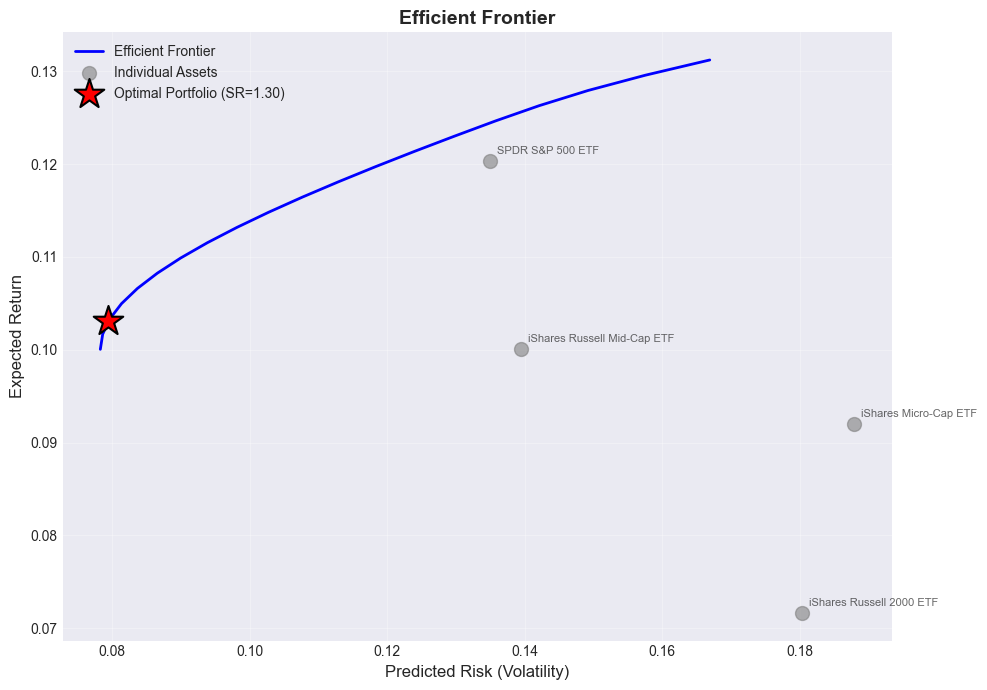

In [85]:
optimizer_instances['20251007'].plot_efficient_frontier(show_assets=True)